# 07 · Mixture fundamentals

Mix 50 mL of ethanol with 50 mL of water and you get about 96 mL. Properties of mixtures are not simply the
sum of the parts - and the concepts that describe how they differ, **partial molar properties** and
**excess properties**, are the foundation of everything that follows: phase equilibria, activity coefficients,
separation processes.

**What you will learn**
- distinguish excess properties from ideal mixing
- compute partial molar properties by the tangent-intercept method
- explain the entropy and Gibbs energy of ideal mixing
- apply the Gibbs-Duhem equation

**Before you start:** notebooks 01 and 06; calculus  ·  **Time:** about 45-60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import datasets, mixtures
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## The volume of ethanol-water mixtures

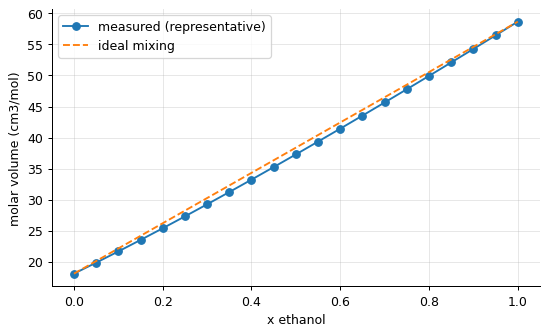

largest contraction at x = 0.45: -1.10 cm3/mol (-3.0%)


In [2]:
d = pd.read_csv(datasets.path("ethanol_water_volume.csv"), comment="#")
x1, V = d.x_ethanol.to_numpy(), d.V_cm3_mol.to_numpy()
V1, V2 = V[-1], V[0]                                                 # pure ethanol and pure water
V_ideal = x1 * V1 + (1 - x1) * V2
plt.plot(x1, V, "o-", label="measured (representative)"); plt.plot(x1, V_ideal, "--", label="ideal mixing")
plt.xlabel("x ethanol"); plt.ylabel("molar volume (cm3/mol)"); plt.legend(); plt.show()
i = np.argmin(V - V_ideal)
print(f"largest contraction at x = {x1[i]:.2f}: {V[i] - V_ideal[i]:.2f} cm3/mol ({(V[i] - V_ideal[i])/V_ideal[i]:.1%})")

The mixture is smaller than the sum of its parts: water and ethanol molecules pack more tightly together
than apart (hydrogen bonding). The difference from ideal mixing is the **excess volume** $V^E$.

## Partial molar volumes
The volume of a mixture is $V = x_1\bar V_1 + x_2\bar V_2$, where $\bar V_i$ - the partial molar volume - is the volume
one mole of $i$ effectively occupies *in the mixture*. It is found from the slope of $V(x_1)$ by the
tangent-intercept construction:

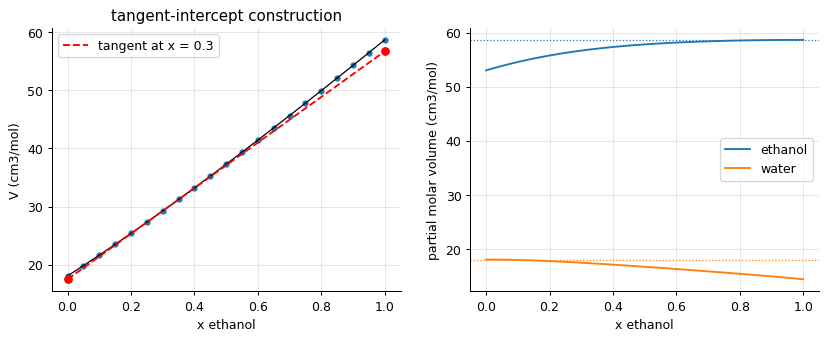

at x = 0.3: V1_bar = 56.69 (pure 58.68), V2_bar = 17.48 (pure 18.07) cm3/mol; check x1 V1_bar + x2 V2_bar = 29.2432 vs V = 29.2432


In [3]:
poly = np.polyfit(x1, V, 6)                                         # smooth representation of the data
Vf = lambda x: np.polyval(poly, x)
xx = np.linspace(0, 1, 100)
Vbar1 = np.array([mixtures.partial_molar_binary(Vf, x)[0] for x in xx])
Vbar2 = np.array([mixtures.partial_molar_binary(Vf, x)[1] for x in xx])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(x1, V, "o", ms=4); a1.plot(xx, Vf(xx), "k", lw=1)
x0 = 0.3
b1, b2 = mixtures.partial_molar_binary(Vf, x0)
a1.plot([0, 1], [b2, b1], "r--", label=f"tangent at x = {x0}"); a1.plot([0, 1], [b2, b1], "ro")
a1.set(xlabel="x ethanol", ylabel="V (cm3/mol)", title="tangent-intercept construction"); a1.legend()
a2.plot(xx, Vbar1, label="ethanol"); a2.plot(xx, Vbar2, label="water")
a2.axhline(V1, color="C0", ls=":", lw=1); a2.axhline(V2, color="C1", ls=":", lw=1)
a2.set(xlabel="x ethanol", ylabel="partial molar volume (cm3/mol)"); a2.legend(); plt.show()
print(f"at x = 0.3: V1_bar = {b1:.2f} (pure {V1:.2f}), V2_bar = {b2:.2f} (pure {V2:.2f}) cm3/mol; check x1 V1_bar + x2 V2_bar = {x0*b1 + (1-x0)*b2:.4f} vs V = {Vf(x0):.4f}")

The tangent's intercepts at $x_1$ = 0 and 1 are the partial molar volumes. At infinite dilution a molecule of
ethanol in water occupies markedly less volume than in pure ethanol - it slips into the water structure.
Partial molar quantities are what mixture calculations actually use: the volume of a tank, the enthalpy of
a stream, and above all the chemical potential (the partial molar Gibbs energy).

## Excess properties and ideal mixing
For an ideal solution $V^E = 0$ and $H^E = 0$, yet mixing still changes the Gibbs energy, through the entropy of
mixing $-R\sum x_i\ln x_i$:

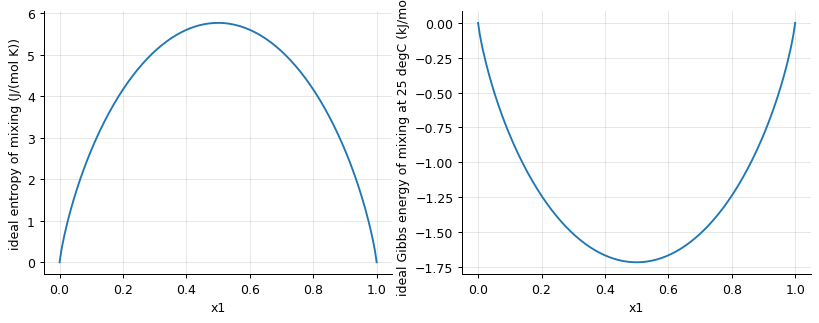

maximum entropy of mixing R ln 2 = 5.763 J/(mol K) at x = 0.5; Gibbs energy of mixing -1.718 kJ/mol


In [4]:
xx = np.linspace(1e-6, 1 - 1e-6, 200)
S_mix = -R * (xx * np.log(xx) + (1 - xx) * np.log(1 - xx))
G_mix = -298.15 * S_mix
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(xx, S_mix); a1.set(xlabel="x1", ylabel="ideal entropy of mixing (J/(mol K))")
a2.plot(xx, G_mix / 1e3); a2.set(xlabel="x1", ylabel="ideal Gibbs energy of mixing at 25 degC (kJ/mol)"); plt.show()
print(f"maximum entropy of mixing R ln 2 = {R*np.log(2):.3f} J/(mol K) at x = 0.5; Gibbs energy of mixing {-298.15*R*np.log(2)/1e3:.3f} kJ/mol")

Mixing is spontaneous even without any energetic effect because the Gibbs energy of mixing is negative;
separating a mixture back into its pure components costs at least that much work - the thermodynamic minimum
behind every distillation column and membrane (notebook 09 makes this quantitative).

## The Gibbs-Duhem equation
The partial molar properties of a mixture are not independent: $\sum x_i\,d\bar M_i = 0$ at constant $T$ and $p$. A
consequence used throughout the course: if one component's partial molar property is known over the whole
composition range, the other's follows.

In [5]:
h = 1e-4
gd = [x * (mixtures.partial_molar_binary(Vf, x + h)[0] - mixtures.partial_molar_binary(Vf, x - h)[0]) / (2 * h)
      + (1 - x) * (mixtures.partial_molar_binary(Vf, x + h)[1] - mixtures.partial_molar_binary(Vf, x - h)[1]) / (2 * h) for x in (0.2, 0.5, 0.8)]
print("Gibbs-Duhem residual x1 dV1_bar/dx1 + x2 dV2_bar/dx1 at x = 0.2, 0.5, 0.8:", np.round(gd, 6))

Gibbs-Duhem residual x1 dV1_bar/dx1 + x2 dV2_bar/dx1 at x = 0.2, 0.5, 0.8: [0. 0. 0.]


The residual is zero (to numerical precision) because both partial molar volumes were derived consistently from
one function $V(x)$. For activity coefficients *measured* separately, the Gibbs-Duhem equation becomes a test of
the data's consistency (notebook 10).

## Inside the algorithm: partial molar properties by differentiating with respect to mole numbers
The definition is $\bar V_i = (\partial(nV)/\partial n_i)_{T,p,n_j}$. Numerically: add a tiny amount of component $i$ to the mixture
and watch the total volume change.

In [6]:
nV = lambda n: (n[0] + n[1]) * Vf(n[0] / (n[0] + n[1]))
print(f"by mole-number derivative: V1_bar = {mixtures.partial_molar(nV, [0.3, 0.7], 0):.4f}, V2_bar = {mixtures.partial_molar(nV, [0.3, 0.7], 1):.4f}")
print(f"by tangent intercepts:     V1_bar = {b1:.4f}, V2_bar = {b2:.4f}")

by mole-number derivative: V1_bar = 56.6896, V2_bar = 17.4805
by tangent intercepts:     V1_bar = 56.6896, V2_bar = 17.4805


## Exercises
1. How much volume is 'lost' when 1 L of ethanol is mixed with 1 L of water at 25 degC? (Densities: ethanol 0.785 g/mL, water 0.997 g/mL; use the data file.)
2. The minimum work to separate 1 mol of an ideal equimolar mixture at 25 degC equals $-\Delta G_{mix}$. Compare it with the heat of vaporisation of benzene (about 31 kJ/mol) to see why distillation uses far more energy than the thermodynamic minimum.
3. **Implement it yourself:** fit the excess volume $V^E = x_1 x_2 (A + B(2x_1 - 1) + C(2x_1 - 1)^2)$ (Redlich-Kister) to the data with `np.linalg.lstsq`, and use it to compute the partial molar volumes at infinite dilution ($\bar V_1^\infty = V_1 + A - B + C$).